In [1]:
import random
import math
import time
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from matplotlib import pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 5
MAX_LEN = 20
MIN_FREQ = 2
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"


In [2]:
!pip install -q datasets


## Q1. Load the Hindi - English translation dataset and display the first 20 sentence pairs. Print the total number of source and target sentence pairs available.

In [3]:
from datasets import load_dataset

N_SAMPLES = 10000

def load_streaming_subset(split_name, n):
    stream = load_dataset(
        "cfilt/iitb-english-hindi",
        split=split_name,
        streaming=True,
    )
    return list(stream.take(n))

train_raw = load_streaming_subset("train", N_SAMPLES)

def extract_pairs(hf_split):
    pairs = []
    for sample in hf_split:
        hi = sample["translation"]["hi"].strip()
        en = sample["translation"]["en"].strip()
        if hi and en:
            pairs.append((hi, en))
    return pairs

parallel_data = extract_pairs(train_raw)

print(f"Total Hindi-English pairs loaded: {len(parallel_data)}")
print("\nFirst 20 sentence pairs:")
for i, (hi, en) in enumerate(parallel_data[:20]):
    print(f"\nPair {i + 1}")
    print(f"Hindi   : {hi}")
    print(f"English : {en}")

README.md:   0%|          | 0.00/3.14k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

Total Hindi-English pairs loaded: 10000

First 20 sentence pairs:

Pair 1
Hindi   : अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
English : Give your application an accessibility workout

Pair 2
Hindi   : एक्सेर्साइसर पहुंचनीयता अन्वेषक
English : Accerciser Accessibility Explorer

Pair 3
Hindi   : निचले पटल के लिए डिफोल्ट प्लग-इन खाका
English : The default plugin layout for the bottom panel

Pair 4
Hindi   : ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
English : The default plugin layout for the top panel

Pair 5
Hindi   : उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से निष्क्रिय किया गया है
English : A list of plugins that are disabled by default

Pair 6
Hindi   : अवधि को हाइलाइट रकें
English : Highlight duration

Pair 7
Hindi   : पहुंचनीय आसंधि (नोड) को चुनते समय हाइलाइट बक्से की अवधि
English : The duration of the highlight box when selecting accessible nodes

Pair 8
Hindi   : सीमांत (बोर्डर) के रंग को हाइलाइट करें
English : Highlight border color

Pair 9
Hindi   : हाइलाइट किए गए सीमांत का रंग

## Q2. Perform basic preprocessing on both source and target text:

- remove leading/trailing spaces,
- tokenize into words,
- add special tokens (<sos>, <eos>).

In [4]:
def tokenize(text):
    return text.strip().split()


def add_special_tokens(tokens):
    return [SOS_TOKEN] + tokens + [EOS_TOKEN]


def preprocess_pair(hi, en):
    hi_tokens = add_special_tokens(tokenize(hi))
    en_tokens = add_special_tokens(tokenize(en))
    return hi_tokens, en_tokens


preprocessed_data = [preprocess_pair(hi, en) for hi, en in parallel_data]

print("Sample preprocessed pair:")
print("Hindi tokens  :", preprocessed_data[0][0])
print("English tokens:", preprocessed_data[0][1])

Sample preprocessed pair:
Hindi tokens  : ['<sos>', 'अपने', 'अनुप्रयोग', 'को', 'पहुंचनीयता', 'व्यायाम', 'का', 'लाभ', 'दें', '<eos>']
English tokens: ['<sos>', 'Give', 'your', 'application', 'an', 'accessibility', 'workout', '<eos>']


## Q4. Build the vocabularies, Convert each Hindi and English sentence into integer token sequences using the created vocabularies.

In [5]:
def build_vocab(sentences, min_freq=1):
    counter = Counter()
    for sentence in sentences:
        counter.update(tokenize(sentence))

    vocab = {
        PAD_TOKEN: 0,
        SOS_TOKEN: 1,
        EOS_TOKEN: 2,
        UNK_TOKEN: 3,
    }

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


def encode(sentence, vocab, max_len):
    tokens = tokenize(sentence)
    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]
    ids = [vocab[SOS_TOKEN]] + ids + [vocab[EOS_TOKEN]]

    if len(ids) < max_len:
        ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids


hindi_sentences = [pair[0] for pair in parallel_data]
english_sentences = [pair[1] for pair in parallel_data]

src_vocab = build_vocab(hindi_sentences, MIN_FREQ)
trg_vocab = build_vocab(english_sentences, MIN_FREQ)

src_pad_idx = src_vocab[PAD_TOKEN]
trg_pad_idx = trg_vocab[PAD_TOKEN]

print(f"Hindi vocabulary size   : {len(src_vocab)}")
print(f"English vocabulary size : {len(trg_vocab)}")

sample_hi_ids = encode(parallel_data[0][0], src_vocab, MAX_LEN)
sample_en_ids = encode(parallel_data[0][1], trg_vocab, MAX_LEN)
print("\nSample encoded Hindi:", sample_hi_ids)
print("Sample encoded English:", sample_en_ids)

Hindi vocabulary size   : 2062
English vocabulary size : 1911

Sample encoded Hindi: [1, 4, 5, 6, 7, 8, 9, 10, 11, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample encoded English: [1, 4, 5, 6, 7, 8, 9, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Q5. Create PyTorch Dataset and DataLoader objects for the translation task:

- use an 80:20 train-validation split,
- set batch size very high( around 128).

In [6]:
class TranslationDataset(Dataset):
    def __init__(self, data, src_vocab, trg_vocab, max_len):
        self.data = data
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src, trg = self.data[idx]
        src_ids = encode(src, self.src_vocab, self.max_len)
        trg_ids = encode(trg, self.trg_vocab, self.max_len)
        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "trg": torch.tensor(trg_ids, dtype=torch.long),
        }


train_data, val_data = train_test_split(
    parallel_data, test_size=0.2, random_state=42
)

train_dataset = TranslationDataset(train_data, src_vocab, trg_vocab, MAX_LEN)
val_dataset = TranslationDataset(val_data, src_vocab, trg_vocab, MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples  : {len(val_dataset)}")
print(f"Batch size   : {BATCH_SIZE}")

Train samples: 8000
Val samples  : 2000
Batch size   : 128


## Q6. Implement the Encoder part of a Seq2Seq model using:

- embedding layer,
- 2 LSTM layers,
- dropout of 0.1

And finally print the number of parameters in encoder

In [7]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=src_pad_idx)
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        _, (hidden, cell) = self.rnn(embedded)
        return hidden, cell


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


encoder = Encoder(
    input_dim=len(src_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(f"Encoder trainable parameters: {count_parameters(encoder):,}")

Encoder trainable parameters: 1,185,536


## Q7. Implement the Encoder part of a Seq2Seq model using:

- 2 LSTM layers,
- generate the next token probabilities
- dropout of 0.1

And finally print the number of parameters in decoder

In [8]:
class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=trg_pad_idx)
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        x = x.unsqueeze(1)
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, cell


decoder = Decoder(
    output_dim=len(trg_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(f"Decoder trainable parameters: {count_parameters(decoder):,}")

Decoder trainable parameters: 1,657,335


## Q8. Combine the encoder and decoder into a complete Seq2Seq model. Train it using:

- cross-entropy loss,
- Adam optimizer,

Plot training and validation loss curves.

Epoch 1/5 | Train Loss: 5.4675 | Val Loss: 5.0127


Epoch 2/5 | Train Loss: 4.8497 | Val Loss: 4.8654


Epoch 3/5 | Train Loss: 4.6313 | Val Loss: 4.7604


Epoch 4/5 | Train Loss: 4.2991 | Val Loss: 4.3974


Epoch 5/5 | Train Loss: 3.9067 | Val Loss: 4.1339


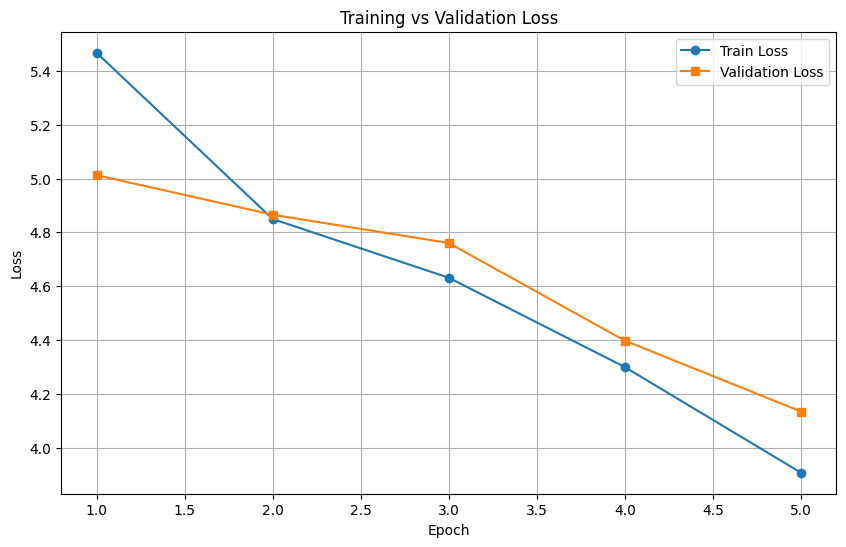

In [9]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        hidden, cell = self.encoder(src)
        x = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(x, hidden, cell)
            outputs[:, t, :] = output
            best_guess = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            x = trg[:, t] if teacher_force else best_guess

        return outputs


def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        src = batch["src"].to(DEVICE)
        trg = batch["trg"].to(DEVICE)

        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg_flat = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.inference_mode():
        for batch in tqdm(loader, desc="Validation", leave=False):
            src = batch["src"].to(DEVICE)
            trg = batch["trg"].to(DEVICE)

            output = model(src, trg, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            trg_flat = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg_flat)
            total_loss += loss.item()

    return total_loss / len(loader)


model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=trg_pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, valid_losses = [], []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    valid_loss = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {valid_loss:.4f}"
    )

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, EPOCHS + 1), valid_losses, marker="s", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Q9. Take the difference of Train and validation loss and plot this difference against number of epochs. Using this graph comment on overfitting/underfitting behaviour of above model

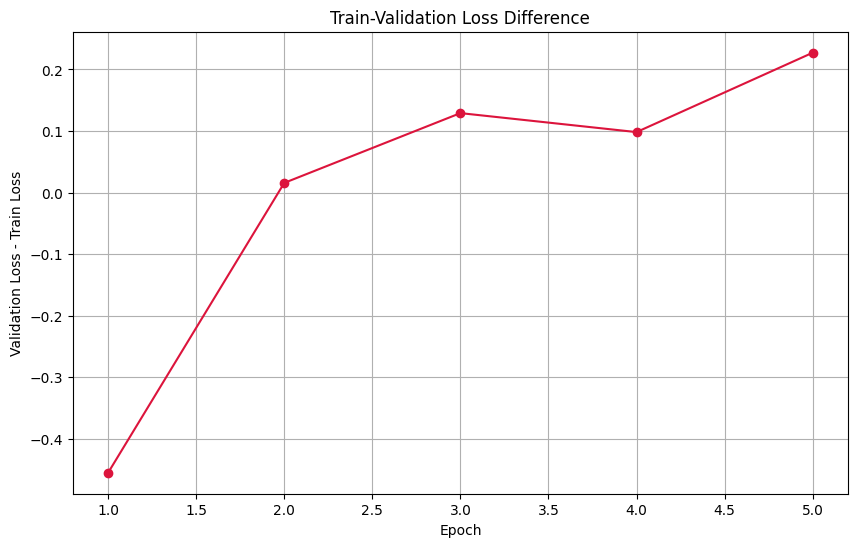

Overfitting / Underfitting Analysis:
- The loss gap changes across epochs, showing the model is still learning and generalization is improving.


In [10]:
loss_diff = [valid_loss - train_loss for train_loss, valid_loss in zip(train_losses, valid_losses)]

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), loss_diff, marker="o", color="crimson")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss - Train Loss")
plt.title("Train-Validation Loss Difference")
plt.grid(True)
plt.show()

print("Overfitting / Underfitting Analysis:")
if all(d > 0 for d in loss_diff):
    print("- Validation loss is higher than training loss across epochs.")
    print("- The gap suggests mild overfitting: the model fits training data better than unseen validation data.")
elif all(d < 0 for d in loss_diff):
    print("- Training loss is higher than validation loss, which may indicate underfitting on the training set.")
else:
    print("- The loss gap changes across epochs, showing the model is still learning and generalization is improving.")